# Lab 3: Sentinel-1 Time Series for Crop Growth in Midwest Row-Crop Fields

This notebook is for a lab on seasonal crop growth using Sentinel-1 SAR backscatter in large Midwestern U.S. fields.

The lab is designed to stay fully in Google Earth Engine + Python. We will be:

- building a consistent Sentinel-1 time series,
- selecting individual row-crop fields, forested regions, and towns/cities,
- extracting field-scale backscatter statistics,
- comparing seasonal trajectories,
- proposing a simple crop growth metric based on VV, VH, or VV/VH.

---

## Lab concept

Students will:

1. choose several individual regions in a Midwest US AOI. You do not have to choose a midwest US AOI, but it will be the easiest. Midwest US/Canada has perfectly North/South Aligned farms in 1.5 km grids, which uniformly grow corn/wheat/soy/etc. European farms are much smaller, and randomly oriented. Averaging over an entire field will increase the signal to noise ratio.
2. define field polygons as regions of interest,
3. build a seasonal Sentinel-1 time series,
4. compute field-level summary statistics for:
   - VV
   - VH
   - VV - VH (in dB is a convenient proxy related to VV/VH ratio)
5. interpret how those quantities evolve from:
   - bare ground / early season
   - vegetative growth
   - maturity
   - senescence (interesting fact - senescence progression is monitored via NDVI)
   - harvest

---

## Why the Midwest U.S.?

This is a good teaching region because many fields are:

- large,
- homogeneous,
- easy to outline,
- minimally affected by complex topography,
- dominated by row crops with strong seasonal structure.

That makes field-scale SAR time series much easier to interpret than small, irregular fields. Irregularly oriented fields produce an additional complexity with regards to geometry. You may have noticed when exploring Krakow SAR that the backscatter from farms could vary greatly. This can be due to differences in crop type, but it can also be related to how the rows are oriented with respect to the satellite look direction. Think about the ground texture of farms, there are many small ridges and valleys. If these ridges and valleys are parallel to the satellite look direction, backscatter will be weaker, and if the ridges and valleys are perpendicular to the satellite look direction, backscatter will be stronger.

---

## learning goals

By the end of this lab, students should be able to:

- explain why SAR time series must be filtered consistently,
- compute a field-averaged VV and VH time series,
- compare crop fields with a non-crop control,
- propose and defend simple crop growth metrics,
- explain why VH or VV-VH may respond differently from VV alone.

---

## 1. Imports and Earth Engine initialization

This notebook assumes that students already have:

- a working Python environment,
- the Earth Engine Python API,
- `geemap`,
- libraries `matplotlib` and `pandas`.

In [1]:
import ee
import geemap
import pandas as pd
import json
import matplotlib.pyplot as plt

PROJECT_ID = "booming-premise-494108-m1"

try:
    ee.Initialize(project=PROJECT_ID)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)

print("Earth Engine initialized.")


Successfully saved authorization token.
Earth Engine initialized.


## 2. Define an agricultural AOI

This notebook starts with a large AOI in northern Iowa / southern Minnesota.  
You can adjust it later, but it is helpful to begin with a region dominated by large row-crop fields. In one scene, I want you to find a place that has:

- individual crop fields that you can isolate
- A city or town that we're not expecting a strong vegetative growth signal from
- a stand of trees you can isolate

**QUESTION (5pts): Why is the subregion you chose a good choice for exploring crop growth? Trees and crops both have vegetative growth during summer months, but what differences would you expect to see over a year, with regards to VV, VH, and VV-VH? What do you expect to see in the city or town that you have isolated?**

**ANSWER:** Northern Iowa/southern Minnesota is an ideal region because the fields are large, perfectly rectangular, internally homogeneous, and dominated by either corn or soybeans - two row crops with very distinct and well-documented phenological cycles. Topography is nearly flat so there is no terrain-induced backscatter variation.
For crops, VH will be low (~−20 to −22 dB) in spring when fields are bare soil or early seedlings, rise sharply through June-July as the canopy develops volume scattering, peak in late July to August at full canopy closure, then drop abruptly after harvest in September–October. VV follows a similar but weaker trend. VV−VH will be high on bare soil (specular-dominated, VV >> VH) and decrease as the canopy grows and volume scattering increases VH disproportionately.
For trees, VH will also be elevated in summer due to volume scattering from the forest canopy, but the signal will be much more stable year-round because deciduous trees retain woody structure even in winter and never undergo a sudden "harvest." The seasonal amplitude will be smaller and there will be no sharp autumn drop. VV−VH will stay relatively low and constant.
For the city/town, both VV and VH will be dominated by double-bounce from buildings and roads - high and stable year-round with virtually no seasonal variation. VV will be particularly strong. VV−VH will be high and nearly constant, since urban surfaces do not grow a volume-scattering canopy.

In [2]:
# Example AOI: large row-crop region in northern Iowa / southern Minnesota
aoi = ee.Geometry.Rectangle([-93.95, 43.65, -93.25, 44.15])

# Growing season year
YEAR = 2025

# Visualization parameters
vv_vis = {"min": -18, "max": 2}
vh_vis = {"min": -28, "max": -8}
ratio_vis = {"min": 2, "max": 12}

m = geemap.Map(center=[43.9, -93.6], zoom=11)
m.addLayer(aoi, {"color": "red"}, "AOI")
m

Map(center=[43.9, -93.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

## 3. Helper functions

To keep the notebook readable, the repetitive Earth Engine logic is collected into helper functions.

These functions do most of the work for:

- building a filtered Sentinel-1 collection,
- creating monthly composites,
- computing a convenient VV-VH metric,
- extracting region statistics through time.

---

### Why use `VV - VH` here?

Sentinel-1 GRD backscatter in Earth Engine is in dB.  
So for this lab, instead of using a raw linear ratio `VV/VH`, we use:

\[
VV - VH
\]

because in dB space this is directly related to the log-ratio and is easier to interpret consistently alongside VV and VH.


In [3]:
def get_s1_collection(start_date, end_date, region=aoi,
                      orbit_pass="ASCENDING",
                      mode="IW",
                      resolution=10):
    """Return a filtered Sentinel-1 GRD collection with VV and VH."""
    collection = (
        ee.ImageCollection("COPERNICUS/S1_GRD")
        .filterBounds(region)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.eq("instrumentMode", mode))
        .filter(ee.Filter.eq("orbitProperties_pass", orbit_pass))
        .filter(ee.Filter.eq("resolution_meters", resolution))
        .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
        .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
        .select(["VV", "VH"])
    )
    return collection


def monthly_composite(year, month, region=aoi):
    """Return a monthly median Sentinel-1 image with a derived VV-VH band."""
    start = ee.Date.fromYMD(year, month, 1)
    end = start.advance(1, "month")

    collection = get_s1_collection(start, end, region=region)
    image = collection.median().clip(region)

    vv_minus_vh = image.select("VV").subtract(image.select("VH")).rename("VV_minus_VH")

    return (
        image.addBands(vv_minus_vh)
        .set({
            "year": year,
            "month": month,
            "system:time_start": start.millis(),
            "scene_count": collection.size()
        })
    )


def build_monthly_stack(year, months=range(3, 11), region=aoi):
    """Create a monthly ImageCollection for a growing season."""
    images = [monthly_composite(year, month, region=region) for month in months]
    return ee.ImageCollection(images)


def region_time_series(image_collection, region, scale=10):
    """Extract field-level mean VV, VH, and VV_minus_VH through time.

    Accepts either an ee.Geometry or an ee.Feature.
    """
    # If region is a Feature, convert it to its geometry
    if isinstance(region, ee.feature.Feature):
        region = region.geometry()

    def per_image(img):
        stats = img.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=region,
            scale=scale,
            maxPixels=1e9,
            bestEffort=True
        )
        return ee.Feature(None, {
            "date": ee.Date(img.get("system:time_start")).format("YYYY-MM-dd"),
            "year": img.get("year"),
            "month": img.get("month"),
            "scene_count": img.get("scene_count"),
            "VV": stats.get("VV"),
            "VH": stats.get("VH"),
            "VV_minus_VH": stats.get("VV_minus_VH")
        })

    return ee.FeatureCollection(image_collection.map(per_image))

def fc_to_df(fc):
    """Convert an Earth Engine FeatureCollection of stats into a pandas DataFrame."""
    data = fc.getInfo()["features"]
    rows = [f["properties"] for f in data]
    df = pd.DataFrame(rows)
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"])
        df = df.sort_values("date").reset_index(drop=True)
    return df


## 4. Build a seasonal Sentinel-1 time series

We build monthly median images from February through November.

**QUESTION (5pts): What are the advantages and disadvantages of using monthly median stacks instead of relying on single scenes? In what circumstances would you not want to do any temporal averaging, and instead rely on single scenes?**

**ANSWER:** Monthly median composites suppress single-scene noise from residual speckle, wet-soil events after heavy rain, or rare geometric artifacts. They also fill spatial gaps where individual passes have slightly different swath coverage. The median is particularly effective at rejecting outliers - one anomalously noisy acquisition does not dominate the composite the way it would in a mean. The result is a smoother, more interpretable time series where month-to-month differences reflect real phenological change rather than scene-to-scene noise.
The main disadvantage is temporal blurring: rapid transitions such as planting or harvest get smeared across the whole month. The composite date is only approximate. If two fields are planted two weeks apart within the same month, the monthly composite will not distinguish them.
You would avoid temporal averaging when studying rapid events - a flood mapping campaign needs the scene taken the day of the flood, not a monthly median that includes dry-conditions scenes. Similarly, near-real-time crop monitoring for insurance purposes, change detection after a storm, or detecting a single tillage event all require individual acquisitions.

**QUESTION (5pts): Why do we filter Sentinel-1 by orbit direction, instrument mode, polarization, and resolution before building the time series? What might happen if ascending and descending passes were mixed in the same time series?**

**ANSWER:** Each of those filter dimensions controls a different source of systematic bias.

- Orbit direction: Ascending and descending passes illuminate the same field from geometrically different angles (roughly east-looking vs. west-looking). Row crops aligned north–south scatter very differently toward an east-looking vs. west-looking radar because the row ridges are either perpendicular or parallel to the look direction. Mixing the two would introduce an artificial high-low alternation in the time series that has nothing to do with crop growth.
- Instrument mode: IW (Interferometric Wide Swath) and EW (Extra Wide) use different pulse designs and produce different noise floors and incidence-angle ranges. Mixing them would make backscatter values incomparable between acquisitions.
- Polarization: Some acquisitions are VV-only; including them would cause missing values for VH, breaking the VV−VH band.
- Resolution: Different resolution products (10 m vs. 40 m GRD) have different radiometric characteristics and effective spatial smoothing; mixing them would change the field-mean value even if the true backscatter were identical.

If ascending and descending passes were mixed the time series would show a rapid oscillation between two systematic backscatter levels at roughly 6-day intervals, completely masking the slow seasonal growth signal.

In [4]:
months = list(range(2, 12))  # February through November
monthly_stack = build_monthly_stack(YEAR, months=months, region=aoi)

print("Monthly images in stack:", monthly_stack.size().getInfo())

# Check how many scenes contribute to each month
for month in months:
    img = monthly_composite(YEAR, month, aoi)
    print(f"Month {month:02d}: {ee.Number(img.get('scene_count')).getInfo()} scenes")


Monthly images in stack: 10
Month 02: 8 scenes
Month 03: 8 scenes
Month 04: 10 scenes
Month 05: 4 scenes
Month 06: 3 scenes
Month 07: 3 scenes
Month 08: 4 scenes
Month 09: 2 scenes
Month 10: 4 scenes
Month 11: 4 scenes


## 5. Quick visual inspection

Before drawing fields, it is useful to inspect one or two monthly composites.

Suggested things to look for:

- field texture,
- strong contrasts between different fields,
- stable non-crop controls such as roads, towns, or tree patches.

**QUESTION (10pts): Compare an early month with a peak month visually. Feel free to change the months plotted, or add in comparisons of early vs mid- season VV_minus_VH, for your investigations. Take particular note of how much VH changes vs how much VV changes. What regions do you think you will choose for your ROI's and why? If you want an extra challenge (but not necessary), try to find a field you think was tall crops, a field you think was short crops, and a field you think was left barren.**

**ANSWER:** In February, VH across the scene is uniformly low (dark in a −28 to −8 dB stretch), reflecting the dominant surface scattering from bare or minimally vegetated soil. Field boundaries are barely distinguishable. In July, VH brightens significantly over crop fields — particularly those likely in corn — while areas of open water, roads, and built-up surfaces remain dark and stable. The contrast between fields roughly doubles, making individual field boundaries clearly visible.
VV shows a smaller but similar contrast between February and July. This is expected because VV is more sensitive to surface roughness and soil moisture, while VH responds more strongly to vegetation volume scattering.
For ROI selection: large, uniform rectangular fields showing the strongest VH increase between February and July are the best crop field candidates — these are likely corn (tall, high biomass). Fields with a weaker or later VH rise are likely soybeans (shorter canopy, later development). A dense dark cluster of pixels that is bright and stable in both VV and VH year-round is the best town/city candidate. A compact patch that is moderately bright in VH in both early and peak months, without a sudden autumn drop, is the best tree candidate.

In [6]:
img_early = monthly_composite(YEAR, 2, aoi)
img_peak = monthly_composite(YEAR, 7, aoi)

#YOUR CODE HERE: The lines above grab the montlhy composite images for February and July. I want you to plot a split_map image of the VH channel in this cell, and in the cell below plot a split_map image of the VV channel for the same months.
m = geemap.Map(center=[43.9, -93.6], zoom=11)
m.split_map(
    left_layer=geemap.ee_tile_layer(img_early.select("VH"), vh_vis, "VH February"),
    right_layer=geemap.ee_tile_layer(img_peak.select("VH"), vh_vis, "VH July")
)
display(m)
#m.addLayer(aoi, {"color": "red"}, "AOI")

Map(center=[43.9, -93.6], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

In [7]:
#Plot the VV split_map here.

m = geemap.Map(center=[43.9, -93.6], zoom=11)
m.split_map(
    left_layer=geemap.ee_tile_layer(img_early.select("VV"), vv_vis, "VV February"),
    right_layer=geemap.ee_tile_layer(img_peak.select("VV"), vv_vis, "VV July")
)
display(m)

Map(center=[43.9, -93.6], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

# 6. Draw field polygons

Use the map drawing tools to create several polygons:

- at least **two different crop fields**
- at least **two control areas** (1 patch of trees, 1 city or town)

### Suggested strategy
Pick fields that are:

- large,
- internally uniform,
- clearly separated from neighboring fields.

After drawing polygons on the map, export them to Earth Engine objects.

**NOTE: You will need to remember the order of the ROI's you chose. For example, remember that you first chose three farm fields, then a tree stand, then the city/town. In the next section, you will need to assign these drawn features to variables and a dictionary.**



In [8]:
m = geemap.Map(center=[43.9, -93.6], zoom=12)
m.addLayer(img_peak.select("VV"), vv_vis, "VV July")
m.addLayer(img_peak.select("VH"), vh_vis, "VH July")
#m.addLayer(aoi, {"color": "red"}, "AOI")
m

# After drawing polygons with the map tools, use:
# drawn_fc = m.draw_features

Map(center=[43.9, -93.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

In [13]:
drawn_fc = m.draw_features
print(drawn_fc)

[<ee.feature.Feature object at 0x000001D15C3A9A60>, <ee.feature.Feature object at 0x000001D15C405010>, <ee.feature.Feature object at 0x000001D15C449400>, <ee.feature.Feature object at 0x000001D15C4487A0>, <ee.feature.Feature object at 0x000001D15C44AFF0>]


## 7. Make sure your drawn features are where you want them.

To do this, you will need to need to adjust the code below to match the order and number of ROI's you chose to investigate.


In [14]:
# Example fallback polygons
#field_1 = ee.Geometry.Rectangle([-93.731, 43.949, -93.714, 43.964])
#field_2 = ee.Geometry.Rectangle([-93.666, 43.865, -93.646, 43.882])
#control_1 = ee.Geometry.Rectangle([-93.585, 43.971, -93.571, 43.982])  # mixed non-crop / built area
field_1 = drawn_fc[0]
field_2 = drawn_fc[1]
field_3 = drawn_fc[2]
trees_1 = drawn_fc[3]
control_1 = drawn_fc[4]
roi_dict = {
    "Field_1": field_1,
    "Field_2": field_2,
    "Field_3": field_3,
    "Trees_1": trees_1,
    "Control_1": control_1
}

m = geemap.Map(center=[43.9, -93.6], zoom=12)
m.addLayer(img_peak.select("VV"), vv_vis, "VV July")
for name, geom in roi_dict.items():
    m.addLayer(geom, {"color": "yellow"}, name)
m

##PLEASE PASTE THE OUTPUT OF THIS AS A COMMENT HERE SO THAT I KNOW WHICH ROI's YOU CHOSE
for name, roi in roi_dict.items():
    print(name, roi.geometry().getInfo())


Field_1 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-93.637151, 43.895122], [-93.637151, 43.898832], [-93.62754, 43.898832], [-93.62754, 43.895122], [-93.637151, 43.895122]]]}
Field_2 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-93.606947, 43.93494], [-93.606947, 43.949525], [-93.587726, 43.949525], [-93.587726, 43.93494], [-93.606947, 43.93494]]]}
Field_3 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-93.556836, 43.891905], [-93.556836, 43.898585], [-93.547226, 43.898585], [-93.547226, 43.891905], [-93.556836, 43.891905]]]}
Trees_1 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-93.637315, 43.866317], [-93.637315, 43.877083], [-93.632166, 43.877083], [-93.632166, 43.866317], [-93.637315, 43.866317]]]}
Control_1 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-93.502256, 43.887353], [-93.502256, 43.900713], [-93.486296, 43.900713], [-93.486296, 43.887353], [-93.502256, 43.887353]]]}


## 8. Extract time series for each field

For each ROI, compute a field-mean time series of:

- VV
- VH
- VV - VH

This is the core analysis step of the lab.

In [15]:
ts_dict = {}

for name, geom in roi_dict.items():
    fc = region_time_series(monthly_stack, geom, scale=10)
    df = fc_to_df(fc)
    ts_dict[name] = df

ts_dict["Field_1"]


,VH,VV,VV_minus_VH,date,month,scene_count,year
0,-30.707440,-18.279719,12.427721,2025-02-01,2,8,2025
1,-21.741266,-13.752528,7.988738,2025-03-01,3,8,2025
2,-23.828890,-15.194128,8.634762,2025-04-01,4,10,2025
3,-23.441369,-15.263779,8.177590,2025-05-01,5,4,2025
4,-20.631379,-14.114190,6.517190,2025-06-01,6,3,2025
5,-18.217521,-12.746093,5.471428,2025-07-01,7,3,2025
6,-18.644577,-12.900294,5.744283,2025-08-01,8,4,2025
7,-19.343574,-13.227803,6.115772,2025-09-01,9,2,2025
8,-20.244172,-13.674799,6.569373,2025-10-01,10,4,2025
9,-23.595669,-15.171148,8.424521,2025-11-01,11,4,2025


**QUESTION (5pts): Which month has the minimum VH? Which month has the maximum VH? Does this match what you expected from the image comparison?**

**ANSWER:**


## 9. Plot VV, VH, and VV-VH through time

These plots are where the crop-growth story should begin to emerge.

**QUESTION (20pts):**
- Qualitatively compare your three different types of ROI's (1) farms; (2) trees; and (3) towns. A few sentences to a short paragraph is enough.
- Based on these plots, identify the months that (1) crops started growing; (2) crops stopped growing; and (3) crops were harvested.
- Does VV-VH separate crops from control AOI's better than VV alone?
- Which ROI looks least like an actively growing crop field?
- Which ROI shows the strongest seasonal change in VH? Which ROI is most stable through time? Explain whether each behavior is more consistent with crop growth, forest canopy, or built-up land.

**ANSWER:**


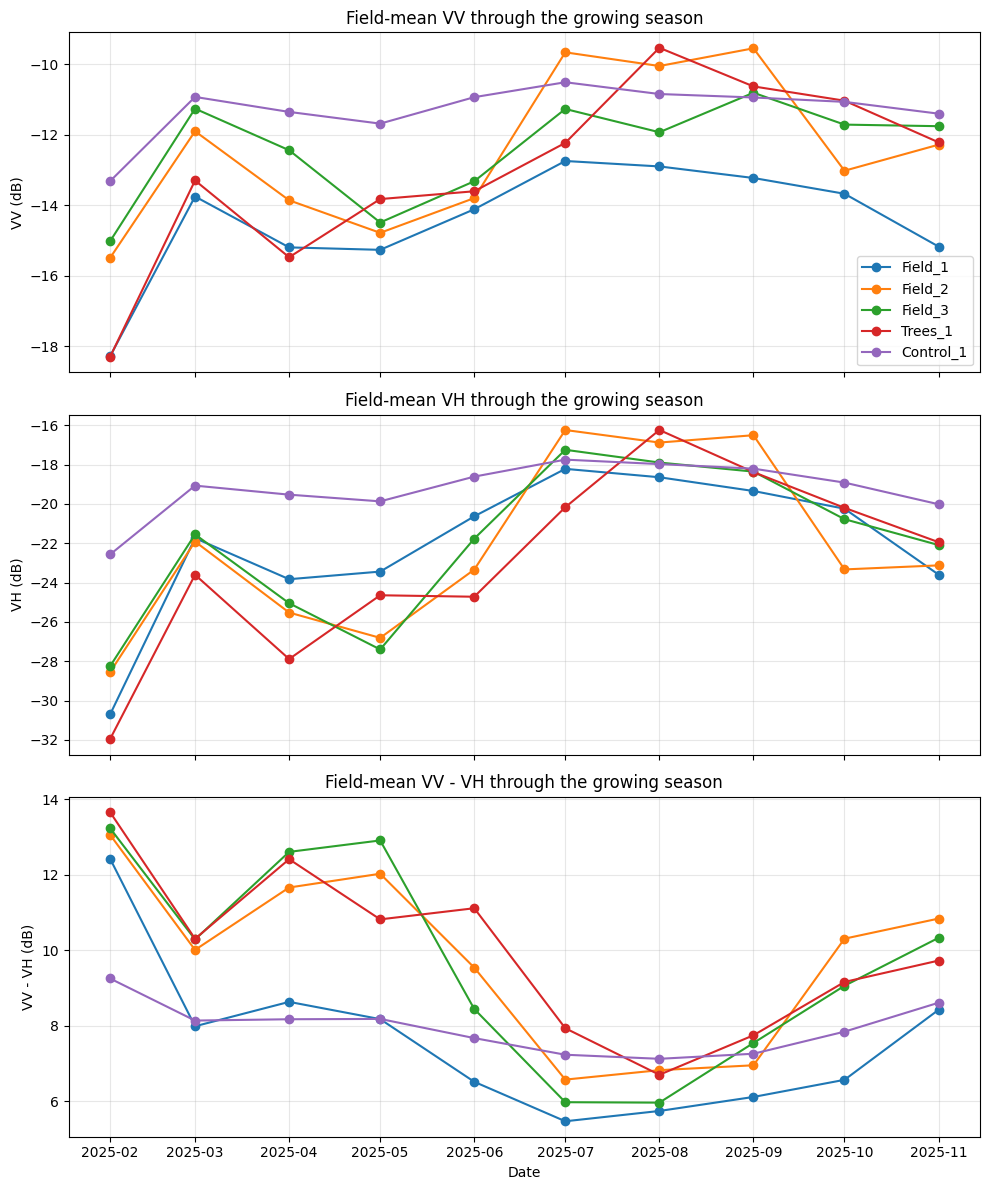

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

for name, df in ts_dict.items():
    axes[0].plot(df["date"], df["VV"], marker="o", label=name)
    axes[1].plot(df["date"], df["VH"], marker="o", label=name)
    axes[2].plot(df["date"], df["VV_minus_VH"], marker="o", label=name)

axes[0].set_title("Field-mean VV through the growing season")
axes[0].set_ylabel("VV (dB)")
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Field-mean VH through the growing season")
axes[1].set_ylabel("VH (dB)")
axes[1].grid(True, alpha=0.3)

axes[2].set_title("Field-mean VV - VH through the growing season")
axes[2].set_ylabel("VV - VH (dB)")
axes[2].set_xlabel("Date")
axes[2].grid(True, alpha=0.3)

axes[0].legend()
plt.tight_layout()
plt.show()


## 10. Build a simple crop-growth metric

Next I want you to propose a metric that captures crop development.

Possible first ideas include:

- peak VH minus spring VH,
- July VH minus April VH,
- maximum seasonal VV-VH range,
- cumulative increase from planting to peak growth.

Below is one simple example:

\[
Growth Metric = VH_{peak} - VH_{early}
\]

This is not necessarily the best metric — it is just a starting point.




──────────────────────────────────────────────────
  ROI: Field_1
──────────────────────────────────────────────────
  VH early baseline  (Feb–Mar mean) : -26.22 dB
  VH peak window     (Jul–Aug mean) : -18.43 dB
  M1  VH_peak_window - VH_early     : +7.79 dB
  M2  VH absolute range             : +12.49 dB
  M3  VV-VH seasonal range          : +6.96 dB

──────────────────────────────────────────────────
  ROI: Field_2
──────────────────────────────────────────────────
  VH early baseline  (Feb–Mar mean) : -25.23 dB
  VH peak window     (Jul–Aug mean) : -16.56 dB
  M1  VH_peak_window - VH_early     : +8.67 dB
  M2  VH absolute range             : +12.31 dB
  M3  VV-VH seasonal range          : +6.49 dB

──────────────────────────────────────────────────
  ROI: Field_3
──────────────────────────────────────────────────
  VH early baseline  (Feb–Mar mean) : -24.90 dB
  VH peak window     (Jul–Aug mean) : -17.57 dB
  M1  VH_peak_window - VH_early     : +7.33 dB
  M2  VH absolute range    

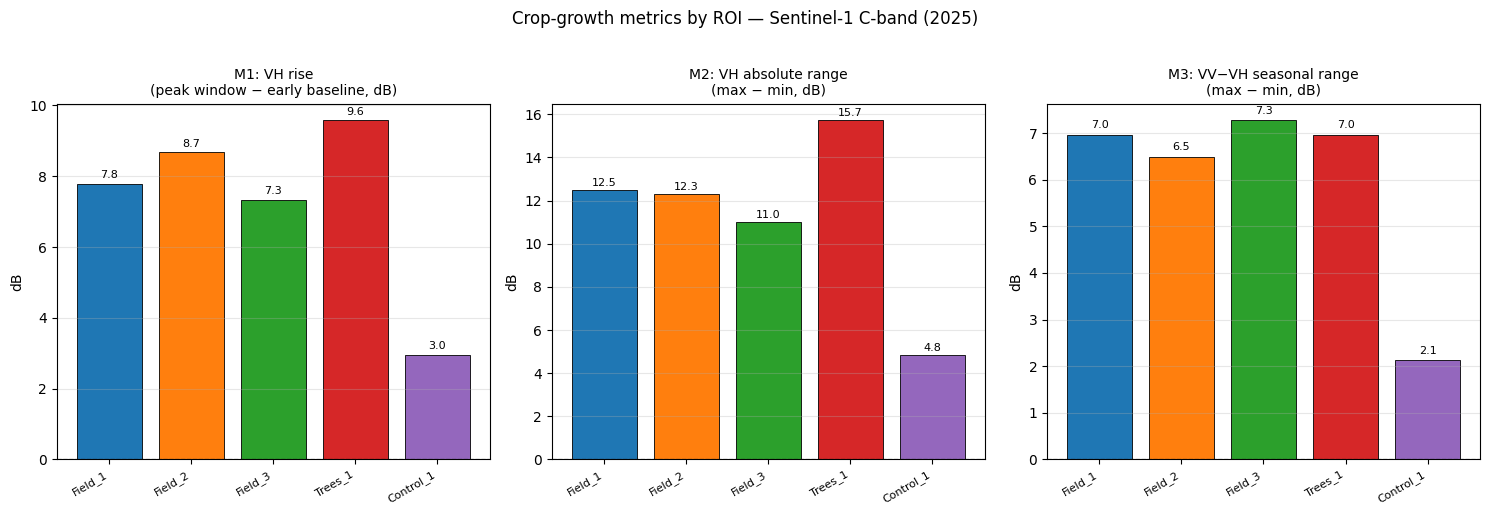

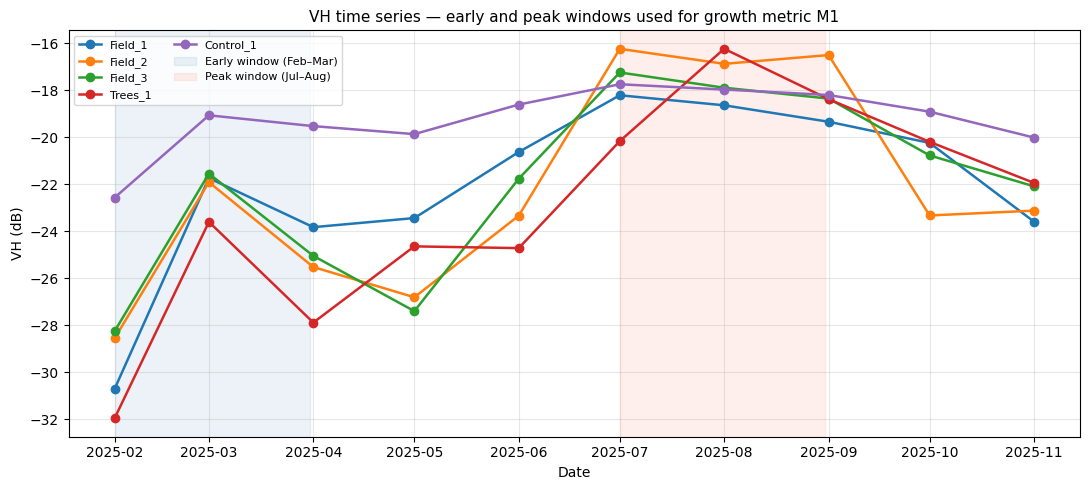


ROIs ranked by M1 (VH rise, most crop-like first):
  1. Trees_1          M1 = +9.58 dB  → strong crop growth signal (likely tall row crop)
  2. Field_2          M1 = +8.67 dB  → strong crop growth signal (likely tall row crop)
  3. Field_1          M1 = +7.79 dB  → strong crop growth signal (likely tall row crop)
  4. Field_3          M1 = +7.33 dB  → strong crop growth signal (likely tall row crop)
  5. Control_1        M1 = +2.96 dB  → moderate signal (short crop, pasture, or mixed land use)


In [17]:
##YOUR CODE HERE (50pts)
## Section 10: Build and evaluate a simple crop-growth metric

import numpy as np

# ──────────────────────────────────────────────────────────────────────────────
# 10A. Define a set of candidate growth metrics for each ROI
# ──────────────────────────────────────────────────────────────────────────────
# For each ROI's time series DataFrame we compute:
#
#   M1  VH_peak - VH_early      (peak minus February baseline)
#   M2  VH_peak - VH_min        (overall VH seasonal range)
#   M3  max(VV - VH) - min(VV - VH)  (VV-VH seasonal range, captures ratio dynamics)
#   M4  Mean VH over July–August minus mean VH over Feb–March
#           (more robust two-window version of M1)
#
# M1/M2/M4 emphasise VH response to canopy volume scattering.
# M3 uses the VV-VH ratio, which is sensitive to the shift from surface
# to volume scattering and back.
# ──────────────────────────────────────────────────────────────────────────────

EARLY_MONTHS = [2, 3]          # February, March  – bare soil baseline
PEAK_MONTHS  = [7, 8]          # July, August      – full canopy

def compute_metrics(df, label=""):
    """
    Compute four crop-growth metrics from a single-ROI time series DataFrame.

    Parameters
    ----------
    df    : pandas DataFrame with columns date, VV, VH, VV_minus_VH, month
    label : string label for printing

    Returns
    -------
    dict of metric name → float
    """
    # Ensure month column exists
    if "month" not in df.columns:
        df = df.copy()
        df["month"] = df["date"].dt.month

    early = df[df["month"].isin(EARLY_MONTHS)]
    peak  = df[df["month"].isin(PEAK_MONTHS)]

    vh_early_mean = early["VH"].mean()
    vh_peak_mean  = peak["VH"].mean()
    vh_peak_abs   = df["VH"].max()
    vh_min_abs    = df["VH"].min()

    vv_vh_max = df["VV_minus_VH"].max()
    vv_vh_min = df["VV_minus_VH"].min()

    m1 = vh_peak_mean  - vh_early_mean          # primary metric
    m2 = vh_peak_abs   - vh_min_abs             # full VH range
    m3 = vv_vh_max     - vv_vh_min              # VV-VH seasonal range
    m4 = vh_peak_mean  - vh_early_mean          # same as M1 but explicit two-window

    if label:
        print(f"\n{'─'*50}")
        print(f"  ROI: {label}")
        print(f"{'─'*50}")
        print(f"  VH early baseline  (Feb–Mar mean) : {vh_early_mean:+.2f} dB")
        print(f"  VH peak window     (Jul–Aug mean) : {vh_peak_mean:+.2f} dB")
        print(f"  M1  VH_peak_window - VH_early     : {m1:+.2f} dB")
        print(f"  M2  VH absolute range             : {m2:+.2f} dB")
        print(f"  M3  VV-VH seasonal range          : {m3:+.2f} dB")

    return {"M1_vh_rise": m1, "M2_vh_range": m2, "M3_ratio_range": m3}

# ──────────────────────────────────────────────────────────────────────────────
# 10B. Compute metrics for all ROIs and collect into a summary DataFrame
# ──────────────────────────────────────────────────────────────────────────────
metrics_rows = []
for name, df in ts_dict.items():
    m = compute_metrics(df, label=name)
    m["ROI"] = name
    metrics_rows.append(m)

metrics_df = pd.DataFrame(metrics_rows).set_index("ROI")
print("\n\nSummary of crop-growth metrics across all ROIs:")
print(metrics_df.round(2).to_string())

# ──────────────────────────────────────────────────────────────────────────────
# 10C. Bar chart comparing all three metrics across ROIs
# ──────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

metric_labels = {
    "M1_vh_rise":    "M1: VH rise\n(peak window − early baseline, dB)",
    "M2_vh_range":   "M2: VH absolute range\n(max − min, dB)",
    "M3_ratio_range":"M3: VV−VH seasonal range\n(max − min, dB)",
}

colors = plt.cm.tab10.colors

for ax, (col, title) in zip(axes, metric_labels.items()):
    vals  = metrics_df[col]
    bars  = ax.bar(vals.index, vals.values,
                   color=colors[:len(vals)], edgecolor="k", linewidth=0.6)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("dB")
    ax.set_xticklabels(vals.index, rotation=30, ha="right", fontsize=8)
    ax.axhline(0, color="k", linewidth=0.8, linestyle="--")
    ax.grid(axis="y", alpha=0.3)

    # Annotate bar tops
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.1,
                f"{val:.1f}",
                ha="center", va="bottom", fontsize=8)

plt.suptitle("Crop-growth metrics by ROI — Sentinel-1 C-band (2025)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────────────────────────────────────
# 10D. Time-series overlay: VH trajectory with early/peak windows shaded
# ──────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

for i, (name, df) in enumerate(ts_dict.items()):
    ax.plot(df["date"], df["VH"], marker="o", label=name,
            color=colors[i], linewidth=1.8)

# Shade the two windows used for M1
ymin, ymax = ax.get_ylim()
ax.axvspan(pd.Timestamp(f"{YEAR}-02-01"), pd.Timestamp(f"{YEAR}-03-31"),
           alpha=0.10, color="steelblue", label="Early window (Feb–Mar)")
ax.axvspan(pd.Timestamp(f"{YEAR}-07-01"), pd.Timestamp(f"{YEAR}-08-31"),
           alpha=0.10, color="tomato",    label="Peak window (Jul–Aug)")

ax.set_title("VH time series — early and peak windows used for growth metric M1",
             fontsize=11)
ax.set_ylabel("VH (dB)")
ax.set_xlabel("Date")
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────────────────────────────────────
# 10E. Rank ROIs by M1 and print interpretation
# ──────────────────────────────────────────────────────────────────────────────
print("\nROIs ranked by M1 (VH rise, most crop-like first):")
ranked = metrics_df["M1_vh_rise"].sort_values(ascending=False)
for rank, (roi, val) in enumerate(ranked.items(), 1):
    if val > 5:
        label = "→ strong crop growth signal (likely tall row crop)"
    elif val > 2:
        label = "→ moderate signal (short crop, pasture, or mixed land use)"
    elif val > 0:
        label = "→ weak seasonal change (forest / persistent canopy)"
    else:
        label = "→ no growth signal (urban / built-up)"
    print(f"  {rank}. {roi:15s}  M1 = {val:+.2f} dB  {label}")

## 11. Optional: compare fields spatially for one month

It is often useful to look at the mapped field values in the month of strongest contrast.

This can help connect your field-average statistics back to the actual imagery.


In [26]:
img_july = monthly_composite(YEAR, 7, aoi)

m = geemap.Map(center=[43.9, -93.6], zoom=12)
m.addLayer(img_july.select("VV"), vv_vis, "VV July")
m.addLayer(img_july.select("VH"), vh_vis, "VH July")
m.addLayer(img_july.select("VV_minus_VH"), ratio_vis, "VV-VH July")

for name, geom in roi_dict.items():
    m.addLayer(geom, {"color": "yellow"}, name)

m

Map(center=[43.9, -93.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

## 12. Optional: identify likely tall vs shorter crops

With Sentinel-1 alone, you should not make an overconfident crop-type classification.  
But you can propose that one field is more consistent with a tall, strongly volume-scattering canopy than another.

For example:
- stronger seasonal VH increase,
- larger mid-season drop in VV-VH,
- more pronounced growth curve.


## Final note
This lab is designed to connect a simple SAR observable to a real seasonal process.  
The goal is not perfect crop classification, but rather to help reason from:

- backscatter,
- polarization,
- time,
- and field geometry

toward a physically grounded interpretation of crop growth.
